In [7]:
!pip install numpy pandas scikit-learn

In [8]:
import numpy as np
import pandas as pd

In [9]:
df = pd.read_csv('DS\Placements.csv')

In [10]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123,1
1,1,5.9,106,0
2,2,5.3,121,0
3,3,7.4,132,1
4,4,5.8,142,0


In [11]:
df.shape

(100, 4)

In [12]:
# steps

# 0. Perprocessing + EDA (Exploratory Data Analysis) + Feature selections
# 1. extract input and output
# 2. Scale the values
# 3. train test split
# 4. train the model
# 5. Evaluate the model / model Selection
# 6. deplay the model

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    int64  
 3   placement   100 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 3.3 KB


In [14]:
df = df.iloc[: ,1:]

In [15]:
df.head()

,cgpa,iq,placement
0,6.8,123,1
1,5.9,106,0
2,5.3,121,0
3,7.4,132,1
4,5.8,142,0


In [16]:
import matplotlib.pyplot as plt


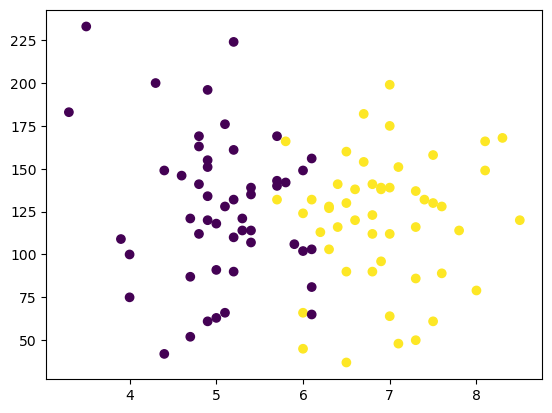

In [17]:
plt.scatter(df['cgpa'] , df['iq'] , c = df['placement'])
#

In [18]:
X = df.iloc[: , 0:-1]
y = df.iloc[: , -1]

In [19]:
X

,cgpa,iq
0,6.8,123
1,5.9,106
2,5.3,121
3,7.4,132
4,5.8,142
...,...,...
95,4.3,200
96,4.4,42
97,6.7,182
98,6.3,103


In [20]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.1)

In [21]:
X_train

,cgpa,iq
47,5.2,161
53,8.3,168
2,5.3,121
86,5.1,128
92,5.2,110
...,...,...
65,8.1,166
59,4.8,112
0,6.8,123
8,6.1,156


In [22]:
X_test

,cgpa,iq
51,4.8,141
34,4.8,163
57,6.5,130
49,5.4,135
79,6.5,90
32,7.0,139
61,7.3,137
97,6.7,182
16,5.2,224
3,7.4,132


In [23]:
y_train

47    0
53    1
2     0
86    0
92    0
     ..
65    1
59    0
0     1
8     0
27    1
Name: placement, Length: 90, dtype: int64

In [24]:
y_test

51    0
34    0
57    1
49    0
79    1
32    1
61    1
97    1
16    0
3     1
Name: placement, dtype: int64

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [26]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [27]:
X_train

array([[-6.69041338e-01,  1.01490263e+00],
       [ 2.01675051e+00,  1.19226425e+00],
       [-5.82402891e-01,  1.40763194e-03],
       [-7.55679784e-01,  1.78769257e-01],
       [-6.69041338e-01, -2.77303492e-01],
       [-1.70870270e+00, -5.30677242e-01],
       [-1.10223357e+00,  1.40763194e-03],
       [ 7.17173808e-01,  5.08155131e-01],
       [-2.35849105e-01,  4.82817756e-01],
       [ 2.40662352e-02, -1.92423286e+00],
       [-2.31517182e+00,  1.57232488e+00],
       [-1.36214891e+00,  7.10854130e-01],
       [-9.28956678e-01,  3.30793506e-01],
       [-9.28956678e-01, -1.51883486e+00],
       [ 1.75683517e+00, -1.06276212e+00],
       [ 8.03812255e-01,  4.32143006e-01],
       [-9.28956678e-01,  7.61528880e-01],
       [ 8.90450701e-01,  1.36962588e+00],
       [ 8.03812255e-01,  4.57480381e-01],
       [-6.69041338e-01,  2.80118756e-01],
       [ 1.41028138e+00, -8.09388366e-01],
       [-9.28956678e-01,  8.62878380e-01],
       [-9.28956678e-01,  1.90171075e+00],
       [ 4.

In [28]:
X_test

array([[-1.01559512,  0.50815513],
       [-1.01559512,  1.06557738],
       [ 0.45725847,  0.22944401],
       [-0.49576444,  0.35613088],
       [ 0.45725847, -0.78405099],
       [ 0.8904507 ,  0.45748038],
       [ 1.15036604,  0.40680563],
       [ 0.63053536,  1.5469875 ],
       [-0.66904134,  2.61115725],
       [ 1.23700449,  0.28011876]])

In [29]:
from sklearn.linear_model import LogisticRegression

In [30]:
clf = LogisticRegression()

In [31]:
#Model Training
clf.fit(X_train ,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [32]:
y_pred = clf.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

1.0

<Axes: >

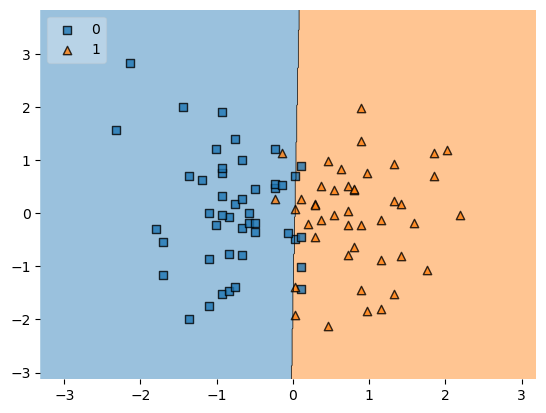

In [37]:

from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train,y_train.values,clf=clf , legend=2)

In [38]:
import pickle
pickle.dump(clf,open('model.pkl','wb'))